In [1]:
import sys
sys.path.insert(0, "/srv/user/azhar.akhmetova/corrViT/scheduled-training/src")  # adjust to your package root

import os
import torch
import pickle
import argparse
import typing as t

from v1t import data
from v1t.utils import utils
from v1t.models.model import Model
from v1t.utils.scheduler import Scheduler
from v1t.utils.attention_rollout import extract_attention_maps

from torch.utils.data import DataLoader

In [2]:
import sys, inspect
import v1t  # or whatever top-level package/module you want to check

print("Imported from:", inspect.getfile(v1t))
print("First few sys.path entries:\n", "\n".join(sys.path[:5]))


Imported from: /srv/user/azhar.akhmetova/corrViT/scheduled-training/src/v1t/__init__.py
First few sys.path entries:
 /srv/user/azhar.akhmetova/corrViT/scheduled-training/src
/user/azhar.akhmetova/miniconda3/envs/rev1t/lib/python310.zip
/user/azhar.akhmetova/miniconda3/envs/rev1t/lib/python3.10
/user/azhar.akhmetova/miniconda3/envs/rev1t/lib/python3.10/lib-dynload



In [3]:
# clustering by ground truth labels  
predictions = torch.load("/user/azhar.akhmetova/sensorium_clusters/syn_data_generation/predictions/predictions_dec_nobehavior_KL_EM_diagcov_alpha_2.1_exp_2_cluster_10_mult_100000000.0_reg_adlognorm_pe10_lr_0.005_seed_1_128.pt")
predictions = predictions.squeeze().detach().cpu().numpy()[:7334]

/tmp/ipykernel_1618242/3600365940.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  predictions = torch.load("/user/azhar.akhmetova/sensorium_clusters/syn_data_generation/

In [4]:
parser = argparse.ArgumentParser()
parser.add_argument("--dataset", type=str, default="/user/azhar.akhmetova/corrViT/refactor/data/sensorium")
parser.add_argument("--output_dir", type=str, required=True)
parser.add_argument("--batch_size", type=int, default=1)
parser.add_argument("--device", type=str, default="cpu")

model_dir = "/user/azhar.akhmetova/corrViT/runs_debug/scheduled-training/k_4_no_subselect_scheduled/k_4_a_03_randsched_nosubsel_bits_1dLL_lrx04_noinit_LLbias_meanbias_s_1_frac0_1_2dpe_bef_core"
args = parser.parse_args([
    "--output_dir", model_dir, # "/user/azhar.akhmetova/corrViT/runs_debug/stabilized-training/k_4_no_subselect/k_4_a_03_nosubsel_bits_regfeatures_lrx04_noinit_LLbias_meanbias_s_1_frac0_1_2dpe_bef_core",
])

In [5]:
args

Namespace(dataset='/user/azhar.akhmetova/corrViT/refactor/data/sensorium', output_dir='/user/azhar.akhmetova/corrViT/runs_debug/scheduled-training/k_4_no_subselect_scheduled/k_4_a_03_randsched_nosubsel_bits_1dLL_lrx04_noinit_LLbias_meanbias_s_1_frac0_1_2dpe_bef_core', batch_size=1, device='cpu')

In [6]:
if not os.path.isdir(args.output_dir):
    raise FileNotFoundError(f"Cannot find {args.output_dir}.")

utils.get_device(args)
utils.set_random_seed(1234)

utils.load_args(args)

_, val_ds, test_ds = data.get_training_ds(
    args,
    data_dir=args.dataset,
    mouse_ids=args.mouse_ids,
    batch_size=args.batch_size,
    device=args.device,
)

model = Model(args, ds=val_ds)
model.eval()

scheduler = Scheduler(args, model=model, save_optimizer=False)
scheduler.restore(force=True)

image shape (1, 144, 256)
num_output_neurons {'k_4_a_03_b1e7_poisson': (7334,)}
Enable gradient checkpointing in ViT

Loaded checkpoint from epoch 73 (correlation: 0.6574).



/srv/user/azhar.akhmetova/corrViT/scheduled-training/src/v1t/utils/scheduler.py:127: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(filename, map_location=s

73

In [8]:
args

Namespace(dataset='/user/azhar.akhmetova/corrViT/refactor/data/sensorium', output_dir='/user/azhar.akhmetova/corrViT/runs_debug/scheduled-training/k_4_no_subselect_scheduled/k_4_a_03_randsched_nosubsel_bits_1dLL_lrx04_noinit_LLbias_meanbias_s_1_frac0_1_2dpe_bef_core', batch_size=1, device=device(type='cpu'), adam_beta1=0.9, adam_beta2=0.999, adam_eps=1e-08, amp=True, backend=None, behavior_mode=0, bias_mode=1, center_crop=1.0, clear_output_dir=True, core='vit', core_lr=0.0006588000000000001, core_reg_scale=0.5379, criterion='poisson', deterministic=True, disable_bias=False, dpi=120, drop_path=0.0, dropout=0.2544, ds_name='sensorium', ds_scale=1, emb_dim_core=156, emb_dim_image=156, emb_dim_input_neurons=152, emb_dim_neuron_id=160, emb_dim_readout=160, epochs=800, eta_min=1e-06, factor=0.3, format='svg', frac_input_neurons=0.1, fraction_min=0.0, fraction_scheduler='random', fraction_warmup_steps=5000, git_hash='7456c43', grad_checkpointing=True, gray_scale=False, hostname='phobos', imag

In [7]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pickle
from sklearn.manifold import TSNE as skTSNE
from openTSNE import TSNE

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

import os, glob
from typing import List, Tuple, Optional
from pathlib import Path
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


In [11]:
id_embeddings = model.neuron_id_tokenizer[args.mouse_ids[0]].embedding.weight.data 
id_embeddings.shape

torch.Size([7334, 160])

In [8]:
features = model.readouts[args.mouse_ids[0]].features.weight.data
features.shape

AttributeError: 'AttentionReadout' object has no attribute 'features'

## TSNE

In [9]:
def perform_tsne(features):
    print(features.shape)
    assert len(features.shape) == 2, "Incorrect feature shape"
    
    n_neurons = features.shape[0]
    
    perplexity = n_neurons / 100
    learning_rate = n_neurons / 12
    
    tsne = skTSNE(
        perplexity=perplexity,
        learning_rate=learning_rate,
        init="pca",
        random_state=42
    )
    
    tsne_result = tsne.fit_transform(features)
    return tsne_result

def perform_opentsne(features):
    print(features.shape)
    assert len(features.shape) == 2, "Incorrect feature shape"
    
    n_neurons = features.shape[0]
    
    perplexity = n_neurons / 100
    learning_rate = n_neurons / 12
    
    tsne = TSNE(
        perplexity=perplexity,
        learning_rate=learning_rate,
        initialization="pca",
        n_jobs=8,
        random_state=42, 
        verbose=True,  # Set verbose to True for detailed output
    )
    
    tsne_result = tsne.fit(features)
    return tsne_result

In [14]:
def plot_tsne(tsne_result, title):
    plt.figure(figsize=(10, 7))
    plt.scatter(tsne_result[:, 0], tsne_result[:, 1], alpha=0.7, s=2)
    plt.title(title)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.show()

In [12]:
try:
    opentsne_id_emb = np.load(os.path.join(args.output_dir, "analysis", "opentsne_id_emb.npy"))
except FileNotFoundError:
    opentsne_id_emb = perform_opentsne(id_embeddings)

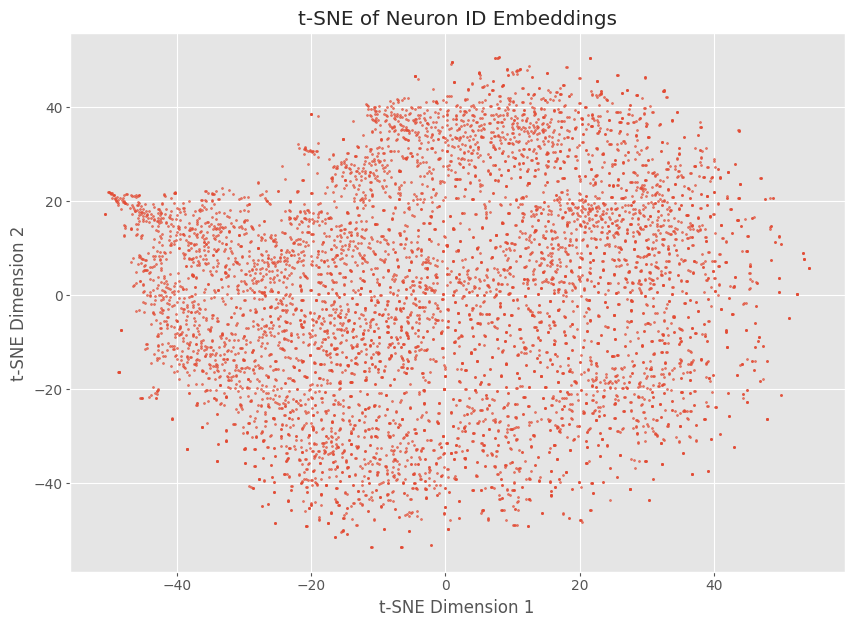

In [15]:
plot_tsne(opentsne_id_emb, "t-SNE of Neuron ID Embeddings")

In [16]:
def plot_tsne_with_clusters(tsne_result, predictions, title="t-SNE colored by cluster labels", figsize=(10, 7)):
    """
    Plot t-SNE results colored by cluster predictions
    
    Args:
        tsne_result: numpy array of shape (n_points, 2) containing t-SNE coordinates
        predictions: numpy array of shape (n_points,) containing cluster labels (0-9 for 10 clusters)
        title: string title for the plot
        figsize: tuple for figure size
    """
    # Convert predictions to numpy if it's a tensor
    if hasattr(predictions, 'detach'):
        predictions = predictions.squeeze().detach().cpu().numpy()
    
    # Get number of unique clusters
    n_clusters = len(np.unique(predictions))
    
    # Create colormap with enough colors for all clusters
    colors = plt.get_cmap("tab10", n_clusters)  # tab10 is good for up to 10 distinct colors
    
    plt.figure(figsize=figsize)
    scatter = plt.scatter(
        tsne_result[:, 0], 
        tsne_result[:, 1], 
        c=predictions,  # Color by cluster predictions
        alpha=0.7, 
        s=5, 
        cmap=colors, 
        edgecolors='k',  
        linewidth=0.1 
    )
    
    # Customize colorbar with cluster labels
    cbar = plt.colorbar(scatter)
    cbar.set_ticks(np.arange(n_clusters))
    cbar.set_ticklabels([f'Cluster {i}' for i in range(n_clusters)])
    cbar.set_label('Cluster Label')
    
    plt.title(title)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.show()



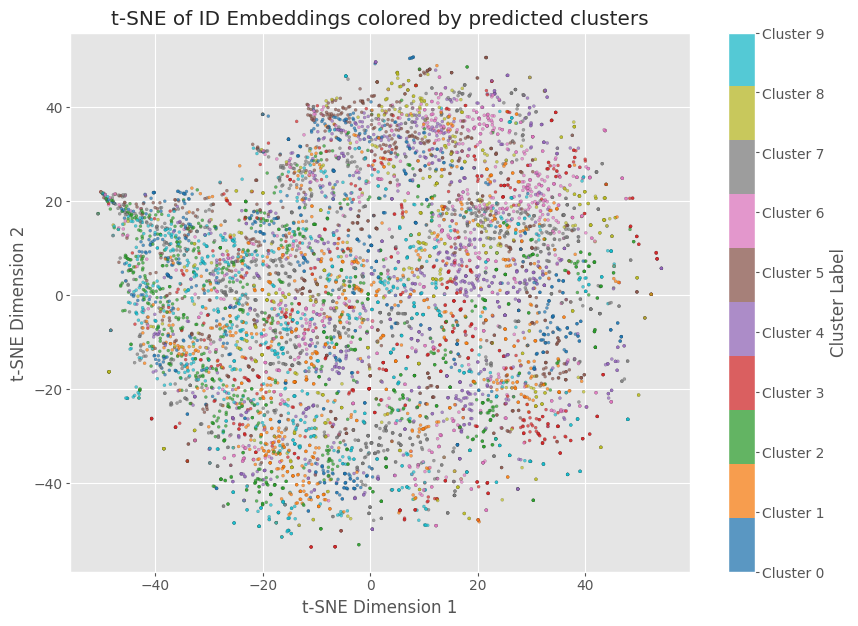

In [17]:
# Plot t-SNE with cluster coloring
plot_tsne_with_clusters(opentsne_id_emb, predictions, "t-SNE of ID Embeddings colored by predicted clusters")

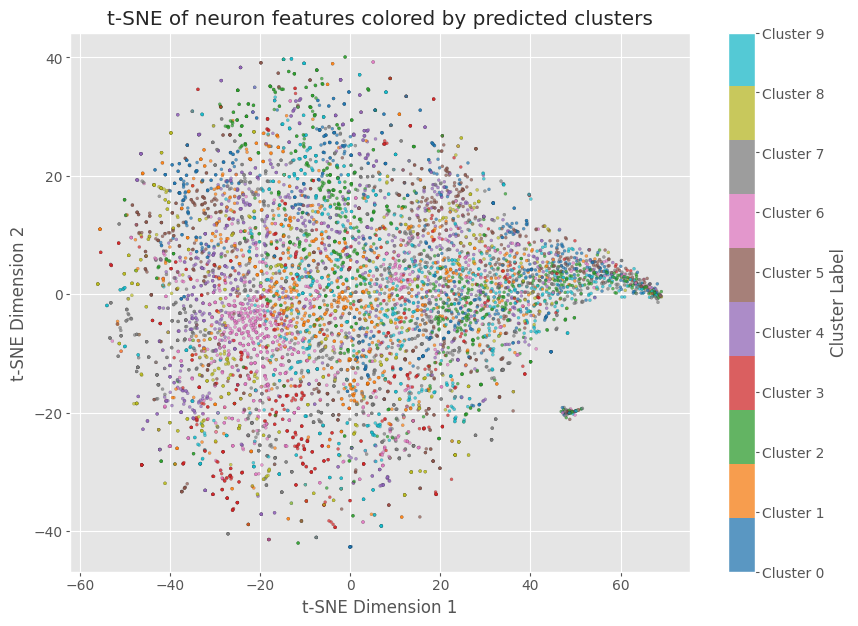

In [13]:
plot_tsne_with_clusters(opentsne_features, predictions, "t-SNE of neuron features colored by predicted clusters")

In [13]:
opentsne_features = perform_opentsne(features)

torch.Size([7334, 160])
--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, learning_rate=611.1666666666666, n_jobs=8,
     perplexity=73.34, random_state=42, verbose=True)
--------------------------------------------------------------------------------
===> Finding 220 nearest neighbors using Annoy approximate search using euclidean distance...
   --> Time elapsed: 4.26 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.14 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.03 seconds
===> Running optimization with exaggeration=12.00, lr=611.17 for 250 iterations...
Iteration   50, KL divergence 4.1363, 50 iterations in 243.2666 sec
Iteration  100, KL divergence 4.1295, 50 iterations in 206.5698 sec
Iteration  150, KL divergence 4.1295, 50 iterations in 254.8471 sec
Iteration  200, KL divergence 4.1295, 50 iterations in 223.1580 sec
Iteration  250, KL divergence 4.1297, 50 iterations in 23

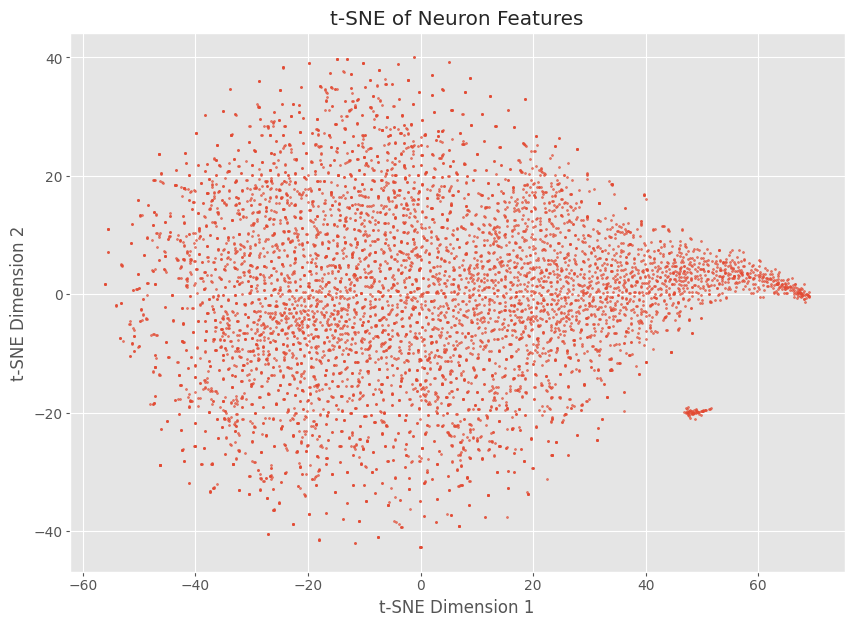

In [14]:
plot_tsne(opentsne_features, "t-SNE of Neuron Features")

In [18]:
os.makedirs(os.path.join(args.output_dir, "analysis"), exist_ok=True)
np.save(os.path.join(args.output_dir, "analysis", "opentsne_id_emb.npy"), opentsne_id_emb)
np.save(os.path.join(args.output_dir, "analysis", "opentsne_features.npy"), opentsne_features)

In [10]:
opentsne_id_emb = np.load(os.path.join(args.output_dir, "analysis", "opentsne_id_emb.npy"))
opentsne_features = np.load(os.path.join(args.output_dir, "analysis", "opentsne_features.npy"))

## AIC/BIC

In [9]:
from sklearn.mixture import GaussianMixture

def GMM(embeddings, seed = 42):
    step_1 = np.arange(1, 11, 1)          # From 1 to 10, step of 1
    step_2 = np.arange(20, 100, 10)       # From 20 to 100, step of 10
    # step_3 = np.arange(131, 156, 1)       # From 131 to 155, step of 1
    # step_4 = np.arange(156, 176, 10)      # From 156 to 175, step of 10

    # Step 2: Concatenate all the ranges
    n_components = np.concatenate([step_1, step_2])
    bic_scores = []
    aic_scores = []

    for n in n_components:
        gmm = GaussianMixture(n_components=n, covariance_type='diag', random_state=seed)
        gmm.fit(embeddings)
        bic_scores.append(gmm.bic(embeddings))
        aic_scores.append(gmm.aic(embeddings))

    return n_components, bic_scores, aic_scores



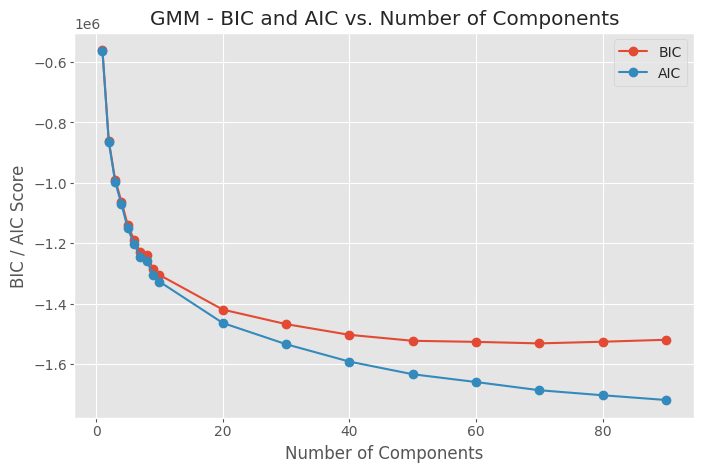

In [10]:
n_aic_bic_id_embeddings = {}

n_components, bic_scores, aic_scores = GMM(id_embeddings.numpy(), seed=42)

n_aic_bic_id_embeddings['n_components'] = n_components
n_aic_bic_id_embeddings['bic_scores'] = bic_scores
n_aic_bic_id_embeddings['aic_scores'] = aic_scores

plt.figure(figsize=(8, 5))
plt.plot(n_components, bic_scores, label='BIC', marker='o')
plt.plot(n_components, aic_scores, label='AIC', marker='o')
plt.xlabel('Number of Components')
plt.ylabel('BIC / AIC Score')
plt.title('GMM - BIC and AIC vs. Number of Components')
plt.legend()
plt.show()

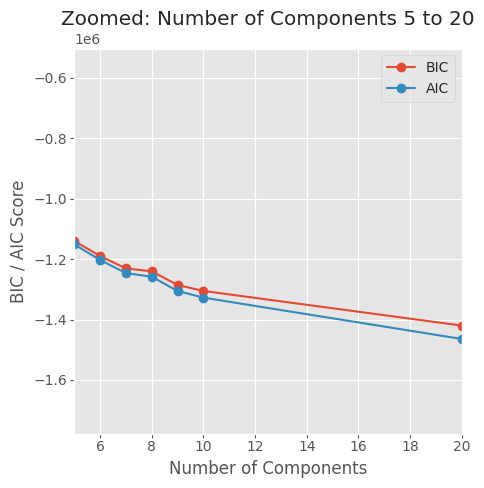

In [11]:
# Create a new figure with one subplot
fig, ax1 = plt.subplots(figsize=(5, 5))

# First plot: Zoomed in on the region from 5 to 20
ax1.plot(n_components, bic_scores, label='BIC', marker='o')
ax1.plot(n_components, aic_scores, label='AIC', marker='o')
ax1.set_xlim(5, 20)
ax1.set_xlabel('Number of Components')
ax1.set_ylabel('BIC / AIC Score')
ax1.set_title('Zoomed: Number of Components 5 to 20')
ax1.legend()
plt.show()

In [13]:
import pickle

os.makedirs(os.path.join(args.output_dir, "analysis"), exist_ok=True)
# Save the dictionary to pickle file
with open(os.path.join(args.output_dir, "analysis", "n_aic_bic_id_embeddings.pkl"), 'wb') as f:
    pickle.dump(n_aic_bic_id_embeddings, f)

In [ ]:
with open(os.path.join(args.output_dir, "analysis", "n_aic_bic_id_embeddings.pkl"), 'rb') as f:
    n_aic_bic_id_embeddings = pickle.load(f)

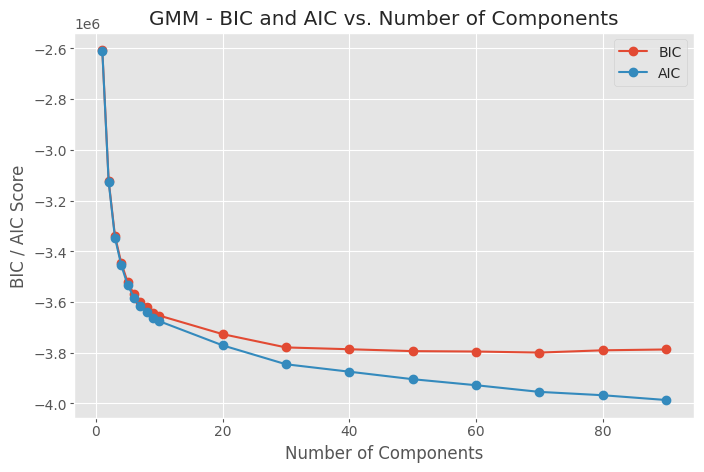

In [19]:
n_aic_bic_features = {}
n_components, bic_scores, aic_scores = GMM(features.numpy(), seed=42)

n_aic_bic_features['n_components'] = n_components
n_aic_bic_features['bic_scores'] = bic_scores
n_aic_bic_features['aic_scores'] = aic_scores

plt.figure(figsize=(8, 5))
plt.plot(n_components, bic_scores, label='BIC', marker='o')
plt.plot(n_components, aic_scores, label='AIC', marker='o')
plt.xlabel('Number of Components')
plt.ylabel('BIC / AIC Score')
plt.title('GMM - BIC and AIC vs. Number of Components')
plt.legend()
plt.show()

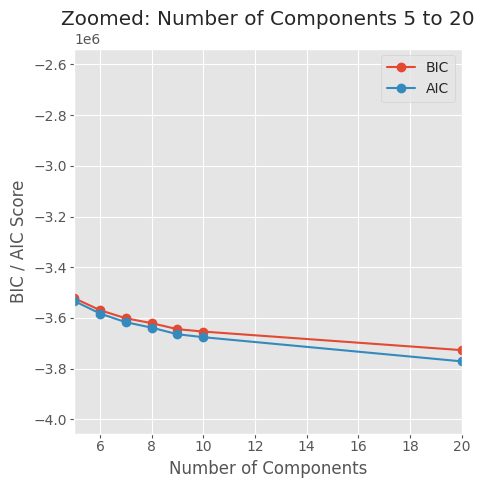

In [20]:
# Create a new figure with one subplot
fig, ax1 = plt.subplots(figsize=(5, 5))

# First plot: Zoomed in on the region from 5 to 20
ax1.plot(n_components, bic_scores, label='BIC', marker='o')
ax1.plot(n_components, aic_scores, label='AIC', marker='o')
ax1.set_xlim(5, 20)
ax1.set_xlabel('Number of Components')
ax1.set_ylabel('BIC / AIC Score')
ax1.set_title('Zoomed: Number of Components 5 to 20')
ax1.legend()
plt.show()

In [23]:
with open(os.path.join(args.output_dir, "analysis", "n_aic_bic_features.pkl"), 'wb') as f:
    pickle.dump(n_aic_bic_features, f)

## ARI

In [18]:
parser = argparse.ArgumentParser()
parser.add_argument("--dataset", type=str, default="/user/azhar.akhmetova/corrViT/refactor/data/sensorium")
parser.add_argument("--output_dir", type=str, required=True)
parser.add_argument("--batch_size", type=int, default=1)
parser.add_argument("--device", type=str, default="cpu")

model_dir_2 = "/user/azhar.akhmetova/corrViT/runs_debug/scheduled-training/k_4_no_subselect_scheduled/k_4_a_03_randsched_nosubsel_bits_1dLL_lrx04_noinit_LLbias_meanbias_s_2_frac0_1_2dpe_bef_core"
args = parser.parse_args([
    "--output_dir", model_dir_2, # "/user/azhar.akhmetova/corrViT/runs_debug/stabilized-training/k_4_no_subselect/k_4_a_03_nosubsel_bits_regfeatures_lrx04_noinit_LLbias_meanbias_s_1_frac0_1_2dpe_bef_core",
])

In [19]:
if not os.path.isdir(args.output_dir):
    raise FileNotFoundError(f"Cannot find {args.output_dir}.")

utils.get_device(args)
utils.set_random_seed(1234)

utils.load_args(args)

_, val_ds, test_ds = data.get_training_ds(
    args,
    data_dir=args.dataset,
    mouse_ids=args.mouse_ids,
    batch_size=args.batch_size,
    device=args.device,
)

model_2 = Model(args, ds=val_ds)
model_2.eval()

scheduler = Scheduler(args, model=model_2, save_optimizer=False)
scheduler.restore(force=True)

image shape (1, 144, 256)
num_output_neurons {'k_4_a_03_b1e7_poisson': (7334,)}
Enable gradient checkpointing in ViT

Loaded checkpoint from epoch 35 (correlation: 0.6596).



35

In [21]:
id_embeddings_2 = model_2.neuron_id_tokenizer[args.mouse_ids[0]].embedding.weight.data


In [ ]:
features_2 = model_2.readouts[args.mouse_ids[0]].features.weight.data

In [27]:
def ari(embeddings_1, embeddings_2):
    # Normalize the embeddings
    embeddings_1 = embeddings_1 / np.linalg.norm(embeddings_1, axis=1, keepdims=True)
    embeddings_2 = embeddings_2 / np.linalg.norm(embeddings_2, axis=1, keepdims=True)
    
    seeds = [10,42]
    step_1 = np.arange(5, 16, 1)          # From 1 to 10, step of 1
    # step_2 = np.arange(20, 110, 10)       # From 20 to 100, step of 10
    # step_3 = np.arange(131, 156, 1)       # From 131 to 155, step of 1
    # step_4 = np.arange(156, 176, 10)      # From 156 to 175, step of 10

    # Step 2: Concatenate all the ranges
    clusters_range = np.concatenate([step_1])
    ari_scores = []

    for n_clusters in clusters_range:
        kmeans_1 = KMeans(n_clusters=n_clusters, random_state=seeds[0])
        kmeans_2 = KMeans(n_clusters=n_clusters, random_state=seeds[1])
        
        labels_1 = kmeans_1.fit_predict(embeddings_1)
        labels_2 = kmeans_2.fit_predict(embeddings_2)
        
        ari = adjusted_rand_score(labels_1, labels_2)
        ari_scores.append(ari)
    return clusters_range, ari_scores



In [28]:
n_ari_id_embeddings = {}

clusters_range_id_emb, ari_scores_id_emb = ari(id_embeddings, id_embeddings_2)

n_ari_id_embeddings['clusters_range'] = clusters_range_id_emb
n_ari_id_embeddings['ari_scores'] = ari_scores_id_emb


In [ ]:
n_ari_features = {}

clusters_range_features, ari_scores_features = ari(features, features_2)


n_ari_features['clusters_range'] = clusters_range_features
n_ari_features['ari_scores'] = ari_scores_features

In [29]:
n_ari_id_embeddings 

{'clusters_range': array([ 5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]),
 'ari_scores': [0.38961721689575723,
  0.35685871792948404,
  0.47608157884992786,
  0.42308910448830545,
  0.39617373754183816,
  0.46163853636209123,
  0.3980326586098504,
  0.3461340328978981,
  0.37045131355473127,
  0.3176676126565507,
  0.3731951154319542]}

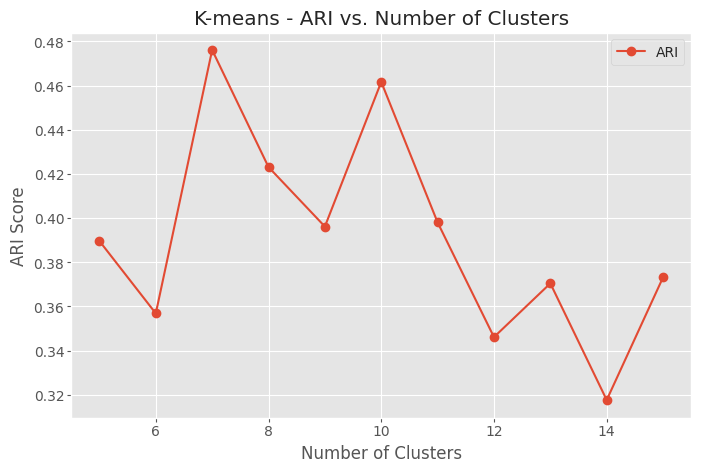

In [30]:
# Plotting ARI scores
plt.figure(figsize=(8, 5))
plt.plot(clusters_range_id_emb, ari_scores_id_emb, label='ARI', marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('ARI Score')
plt.title('K-means - ARI vs. Number of Clusters')
plt.legend()
plt.show()

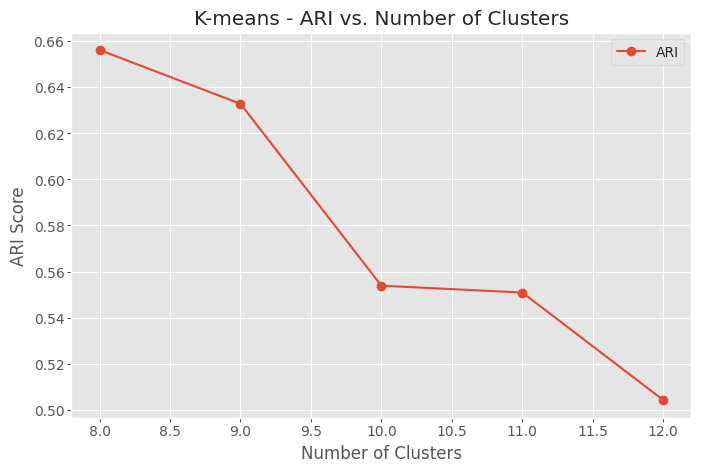

In [28]:
# Plotting ARI scores
plt.figure(figsize=(8, 5))
plt.plot(clusters_range_features, ari_scores_features, label='ARI', marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('ARI Score')
plt.title('K-means - ARI vs. Number of Clusters')
plt.legend()
plt.show()

In [ ]:
with open(os.path.join(args.output_dir, "analysis", "n_ari_id_embeddings.pkl"), 'wb') as f:
    pickle.dump(n_ari_id_embeddings, f)
with open(os.path.join(args.output_dir, "analysis", "n_ari_features.pkl"), 'wb') as f:
    pickle.dump(n_ari_features, f)

In [17]:
def gt_ari(embeddings, predictions, n_clusters, seed=0):
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    X = embeddings / np.clip(norms, 1e-12, None)

    y_true = predictions.astype(int)

    km = KMeans(n_clusters=n_clusters, random_state=seed)
    y_pred = km.fit_predict(X)
    return adjusted_rand_score(y_true, y_pred)

In [19]:
ari_score_gt_id_emb = gt_ari(id_embeddings, predictions, n_clusters=10, seed=42)

In [ ]:
ari_score_gt_features = gt_ari(features, predictions, n_clusters=10, seed=42)

In [20]:
ari_score_gt_id_emb

0.03945558882842227

In [46]:
ari_score_gt_features

0.03269220929728074